In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)


Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [5]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBill

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Target Variable Distribution

In [8]:
df["Churn"].value_counts()


,count
Churn,
No,5174
Yes,1869


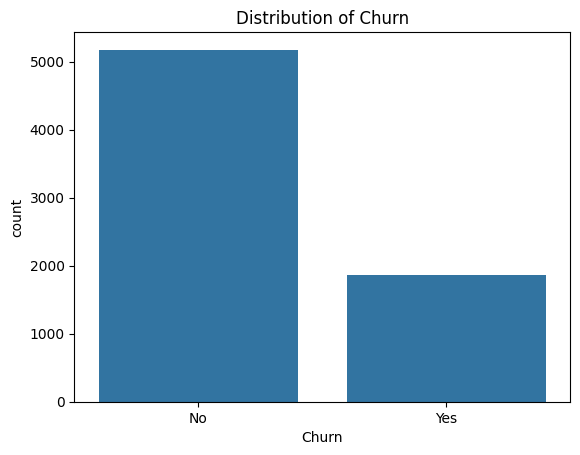

In [9]:
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.show()

### Observation

The target variable is binary:
- **Yes** = customer churned
- **No** = customer did not churn

The dataset appears to have more non-churn customers than churn customers.

##Data Preprocessing

In [10]:
#Drop CustomerID
df.drop("customerID", axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
#Fix TotalCharges Column
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

In [12]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_39128/1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [13]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [14]:
#Encode Target Variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [15]:
# Identify Feature Types
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(exclude=["object"]).columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')


In [16]:
#Encode Categorical Features
df = pd.get_dummies(df, drop_first=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


##Data Analysis

In [ ]:
# Gender vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=original_df)
plt.title("Churn by Gender")
plt.show()

Observation:
Both male and female customers have similar churn patterns. Gender does not appear to strongly affect customer churn.

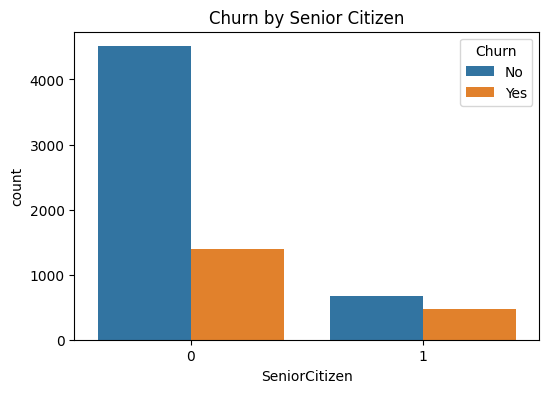

In [ ]:
# Senior Citizen vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=original_df)
plt.title("Churn by Senior Citizen")
plt.show()

Observation:
Senior citizens appear to have a higher proportion of churn compared to non-senior customers.

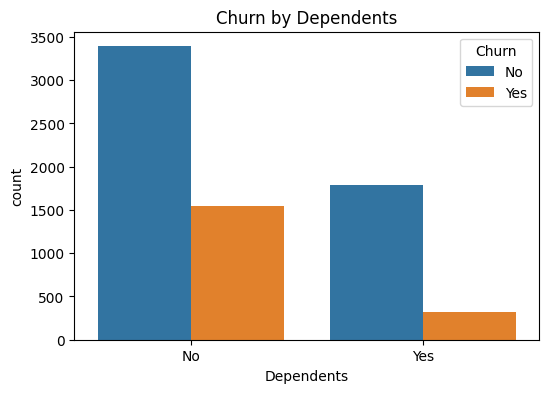

In [ ]:
# Dependents vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x="Dependents", hue="Churn", data=original_df)
plt.title("Churn by Dependents")
plt.show()

Observation:
Customers without dependents are more likely to churn than customers with dependents.

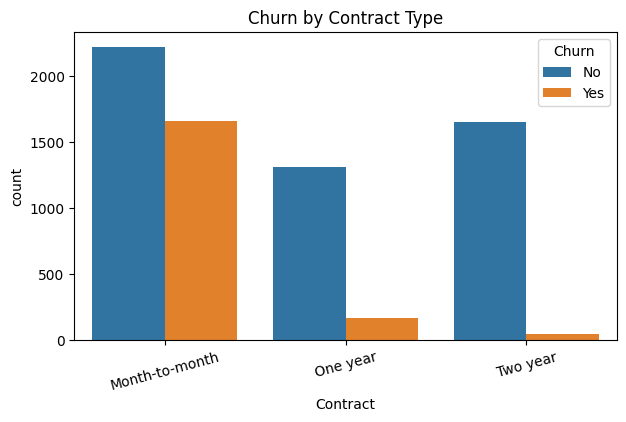

In [ ]:
# Contract vs Churn
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=original_df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

Observation:
Customers with month-to-month contracts have a much higher churn rate compared to customers with longer-term contracts.

This suggests that contract type is an important factor in predicting churn.

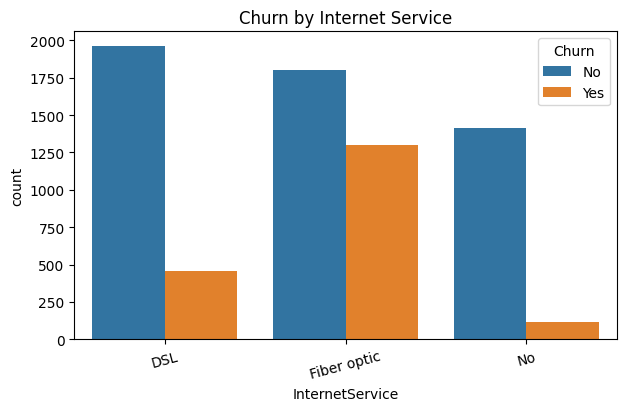

In [ ]:
# Internet Service vs Churn
plt.figure(figsize=(7,4))
sns.countplot(x="InternetService", hue="Churn", data=original_df)
plt.title("Churn by Internet Service")
plt.xticks(rotation=15)
plt.show()

Observation:
Customers using fiber optic service appear to have a higher churn rate compared to other service types.

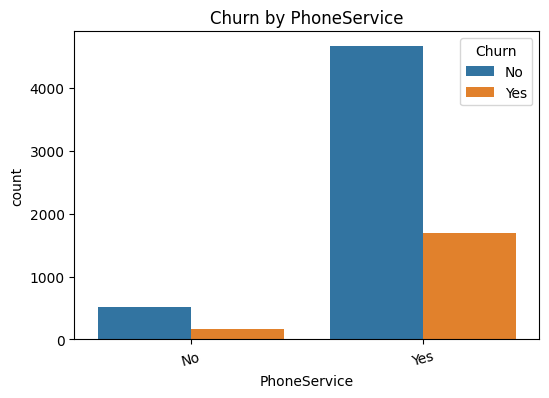

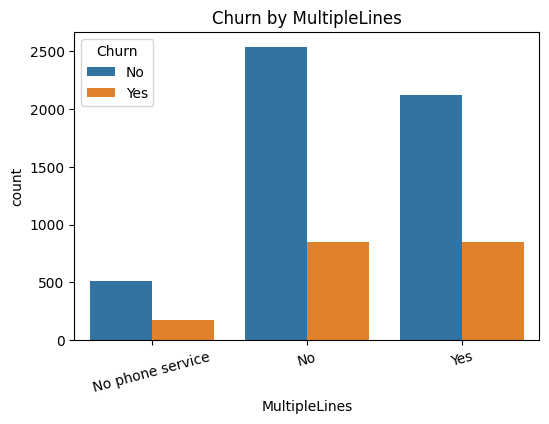

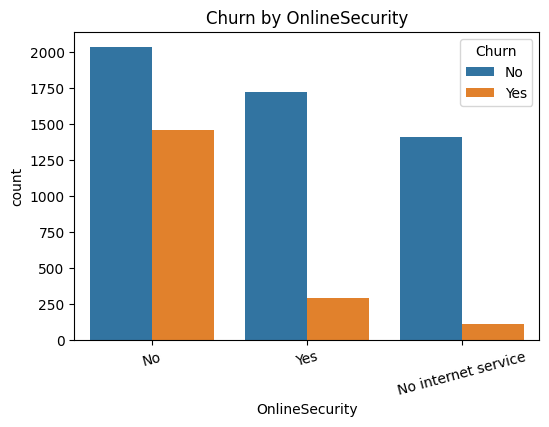

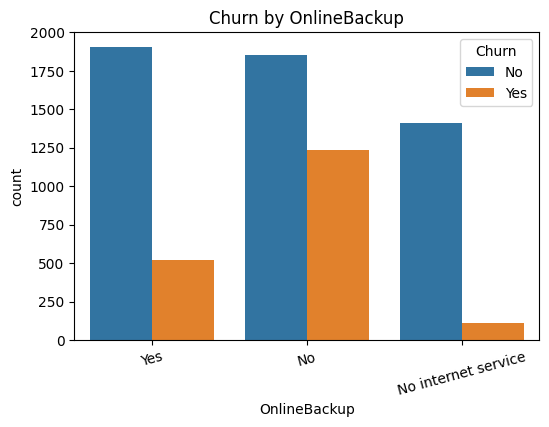

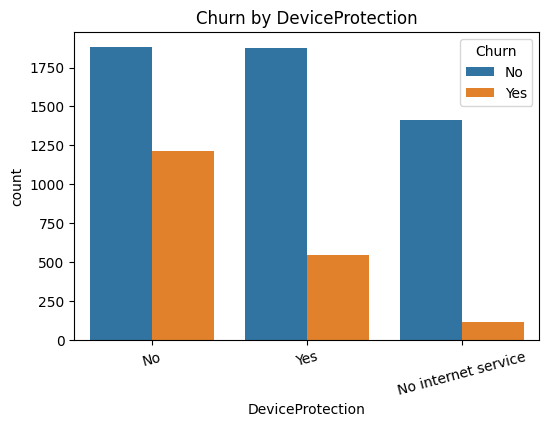

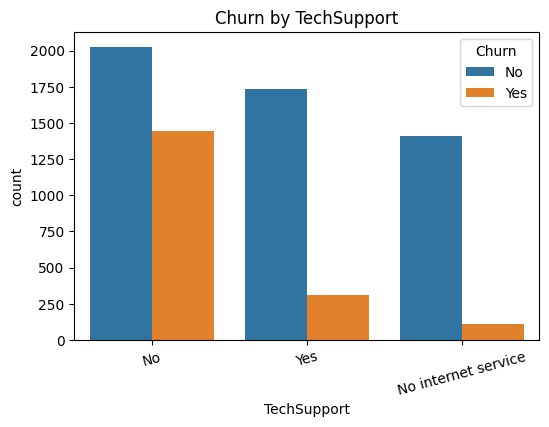

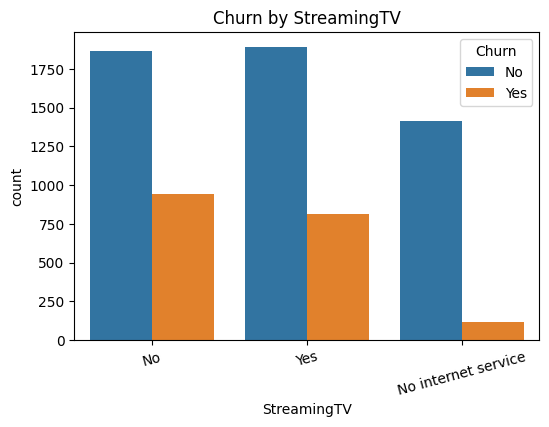

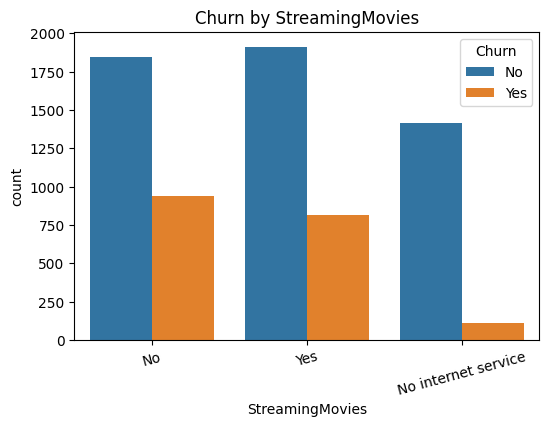

In [ ]:
# Service Columns vs Churn
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Churn", data=original_df)
    plt.title(f"Churn by {col}")
    plt.xticks(rotation=15)
    plt.show()

Observation:
Customers who do not have additional services such as OnlineSecurity, TechSupport, or OnlineBackup tend to churn more.

This suggests that value-added services may help reduce customer churn.

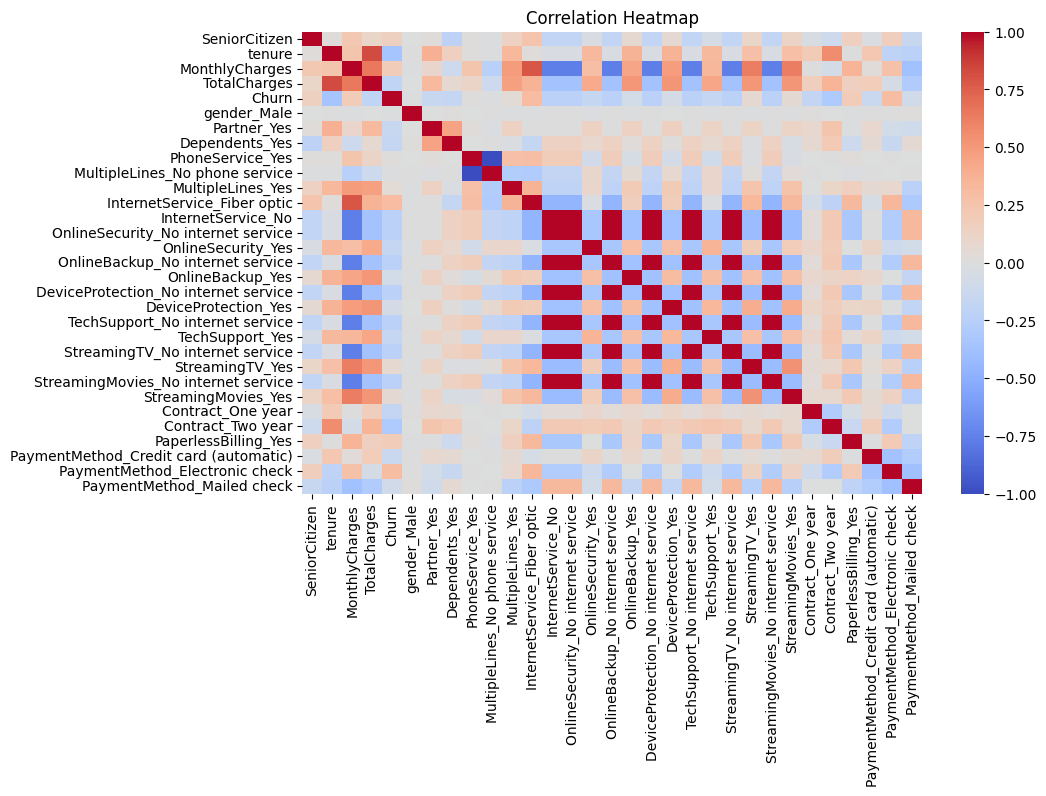

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Observation

Some encoded features show stronger relationships with churn than others. Correlation does not prove causation, but it gives useful insights.

In [22]:
# Feature and Target Split
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 30)
y shape: (7043,)


In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5634, 30)
Testing set shape: (1409, 30)


In [24]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Model 1: Logistic Regression

Logistic Regression is a classification algorithm used to predict a binary target. In this project, it predicts whether a customer will churn or not churn.

In [25]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [26]:
y_pred_lr = lr.predict(X_test_scaled)

In [27]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8069552874378992


In [28]:
print("Classification Report for Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



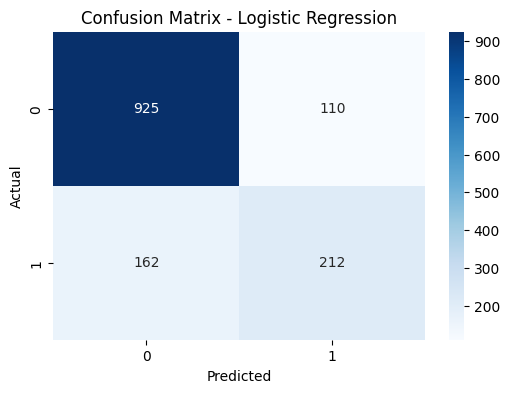

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretation

The confusion matrix shows how many customers were correctly and incorrectly classified. The classification report gives precision, recall, f1-score, and support for both classes.

A good churn model should not only have good accuracy, but should also perform well in identifying customers who are likely to churn.

##Model 2: Decision Tree

Decision Tree is a classification model that makes decisions by splitting data based on feature values. It is easy to interpret and explain.

In [30]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [31]:
y_pred_dt = dt.predict(X_test)

In [32]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.794180269694819


In [33]:
print("Classification Report for Decision Tree:\n")
print(classification_report(y_test, y_pred_dt))

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



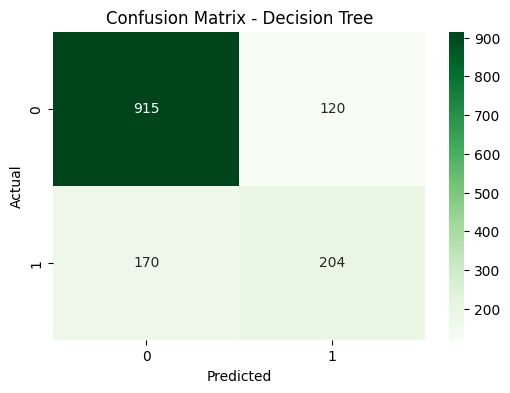

In [34]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretation

Decision Tree is easier to explain because it follows a clear rule-based structure. However, its performance may be lower than Logistic Regression depending on the data and parameter settings.

##Compare Model Performance

In [35]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [lr_accuracy, dt_accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.806955
1,Decision Tree,0.794180


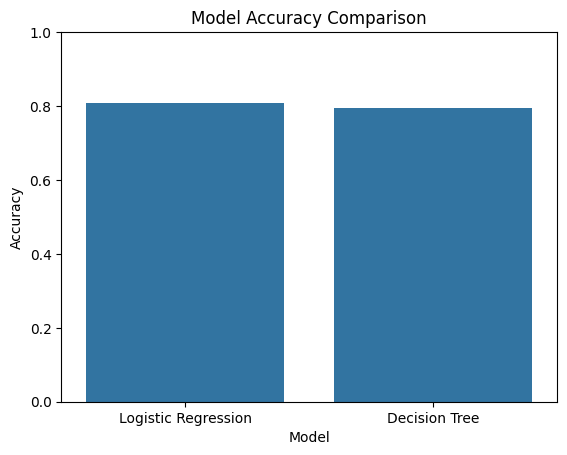

In [36]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

#### Observation

The model with higher accuracy can be considered the better performer in this implementation. However, accuracy should be interpreted together with precision, recall, and f1-score, especially for churn prediction.

##FEATURE SELECTION EXPERIMENT

# Round 1: Model Training with All Features

In this step, the models are trained using all preprocessed features.
This represents the baseline model performance before feature selection.

In [37]:
# Logistic Regression (All Features)
lr1 = LogisticRegression(max_iter=1000, random_state=42)
lr1.fit(X_train_scaled, y_train)

y_pred_lr1 = lr1.predict(X_test_scaled)

# Decision Tree (All Features)
dt1 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt1.fit(X_train, y_train)

y_pred_dt1 = dt1.predict(X_test)

In [38]:
print("ROUND 1 - ALL FEATURES\n")

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr1))
print(classification_report(y_test, y_pred_lr1))

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt1))
print(classification_report(y_test, y_pred_dt1))

ROUND 1 - ALL FEATURES

Logistic Regression Accuracy: 0.8069552874378992
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Decision Tree Accuracy: 0.794180269694819
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



# Round 2: Feature Selection

In this step, feature selection is applied to keep only the most relevant features.

Correlation with the target variable (Churn) is used to select important features.
Features with very low correlation are removed.

In [39]:
corr = df.corr()

# correlation with target
churn_corr = corr["Churn"].sort_values(ascending=False)
churn_corr

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
PaperlessBilling_Yes,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
PhoneService_Yes,0.011942


In [40]:
selected_features = churn_corr[abs(churn_corr) > 0.05].index
selected_features

Index(['Churn', 'InternetService_Fiber optic',
       'PaymentMethod_Electronic check', 'MonthlyCharges',
       'PaperlessBilling_Yes', 'SeniorCitizen', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'DeviceProtection_Yes', 'OnlineBackup_Yes',
       'PaymentMethod_Mailed check', 'PaymentMethod_Credit card (automatic)',
       'Partner_Yes', 'Dependents_Yes', 'TechSupport_Yes',
       'OnlineSecurity_Yes', 'Contract_One year', 'TotalCharges',
       'InternetService_No', 'StreamingTV_No internet service',
       'OnlineSecurity_No internet service',
       'OnlineBackup_No internet service',
       'DeviceProtection_No internet service',
       'StreamingMovies_No internet service',
       'TechSupport_No internet service', 'Contract_Two year', 'tenure'],
      dtype='object')

In [41]:
selected_features = selected_features.drop("Churn")

In [42]:
X_selected = df[selected_features]
y = df["Churn"]

In [43]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
scaler2 = StandardScaler()

X_train_s_scaled = scaler2.fit_transform(X_train_s)
X_test_s_scaled = scaler2.transform(X_test_s)

In [45]:
# Logistic Regression
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train_s_scaled, y_train_s)

y_pred_lr2 = lr2.predict(X_test_s_scaled)

# Decision Tree
dt2 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt2.fit(X_train_s, y_train_s)

y_pred_dt2 = dt2.predict(X_test_s)

In [46]:
print("ROUND 2 - SELECTED FEATURES\n")

print("Logistic Regression Accuracy:", accuracy_score(y_test_s, y_pred_lr2))
print(classification_report(y_test_s, y_pred_lr2))

print("Decision Tree Accuracy:", accuracy_score(y_test_s, y_pred_dt2))
print(classification_report(y_test_s, y_pred_dt2))

ROUND 2 - SELECTED FEATURES

Logistic Regression Accuracy: 0.7977288857345636
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Decision Tree Accuracy: 0.794180269694819
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1035
           1       0.62      0.59      0.60       374

    accuracy                           0.79      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [47]:
comparison = pd.DataFrame({
    "Model": ["LogReg (All)", "DT (All)", "LogReg (Selected)", "DT (Selected)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr1),
        accuracy_score(y_test, y_pred_dt1),
        accuracy_score(y_test_s, y_pred_lr2),
        accuracy_score(y_test_s, y_pred_dt2)
    ]
})

comparison

,Model,Accuracy
0,LogReg (All),0.806955
1,DT (All),0.794180
2,LogReg (Selected),0.797729
3,DT (Selected),0.794180


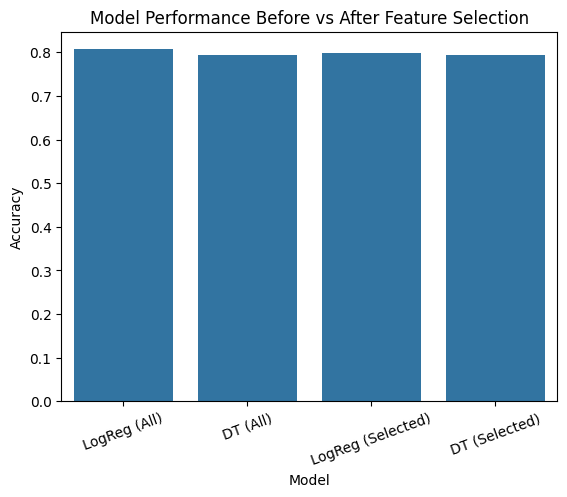

In [48]:
 sns.barplot(x="Model", y="Accuracy", data=comparison)
plt.title("Model Performance Before vs After Feature Selection")
plt.xticks(rotation=20)
plt.show()

# Comparison Before and After Feature Selection

After applying feature selection, the model performance was compared with the baseline.

Observations:
- Logistic Regression showed improved performance after feature selection.
- Decision Tree performance changed slightly depending on selected features.
- Removing less important features helps reduce noise and improve model generalization.

This matches the approach used in the research paper, where models were evaluated before and after feature selection.